# Lab 2 – From Raw Data to ML-Ready Data: Telco Customer Churn EDA

**Name:** Abdul Wali
**CMS ID:** 023-24-0174

## Part 1 — The Business Problem

**1. Business problem & target variable**

The company is bleeding customers to competitors and wants to catch the ones who are about to leave before they actually do, since keeping an existing customer is a lot cheaper than winning a new one. Each row in this dataset is one customer's full profile — who they are, what services they've signed up for, how they pay, and whether they eventually left. The target variable is clearly **Churn** (Yes/No).

**2. Predictors I expect to matter (and two that probably won't)**

Useful:
- `Contract` — month-to-month customers can leave anytime, so I'd expect them to churn a lot more.
- `tenure` — newer customers have had less time to feel "locked in."
- `InternetService` — fiber optic is pricier, might frustrate people more.
- `MonthlyCharges` — higher bills, more reason to shop around.
- `PaymentMethod` — manual payment methods might correlate with less commitment.

Probably useless:
- `customerID` — a random ID string, can't carry any real signal.
- `gender` — no real reason a person's gender would affect whether they cancel internet service.

**3. Two things I actually want to know**

1. Do month-to-month customers really churn that much more than customers on longer contracts?
2. Is there a service or payment habit that's quietly driving people away, or is churn mostly just about price and contract flexibility?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.xls')
df.shape

(7043, 21)

## Part 2 — Exploring the Dataset Structure

In [2]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numeric_cols, categorical_cols

(['SeniorCitizen', 'tenure', 'MonthlyCharges'], ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn'])

**4. Shape & feature types**

7,043 customers, 21 columns (20 features + `Churn`). Right now pandas only reads `SeniorCitizen`, `tenure` and `MonthlyCharges` as numeric — everything else, including `TotalCharges`, comes in as text. That last one is wrong and I'll fix it in a second.

In [5]:
df['customerID'].nunique(), len(df)

(7043, 7043)

**5. Identifiers & wrong data types**

`customerID` is unique for all 7,043 rows — it's a pure identifier, not a predictor. `TotalCharges` is stored as an object even though it's clearly numeric. `SeniorCitizen` is stored as 0/1 integers when it's really a Yes/No flag like the rest of the demographic columns.

In [6]:
print(df['Contract'].unique())
print(df['InternetService'].unique())
print(df['MultipleLines'].unique())

<StringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str


**6. Three categorical columns, checked for weirdness**

`Contract` and `InternetService` are exactly what I'd expect, no surprises. `MultipleLines` has a `'No phone service'` category — not an error, just a different way of saying "No," since that customer never had phone service to begin with. Worth remembering for later, but not something that needs fixing.

## Part 3 — Investigating Data Quality

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Nothing missing according to `isnull()` — which is a little too clean for a real dataset, so I kept digging.

In [8]:
(df['TotalCharges'].str.strip() == '').sum()

np.int64(11)

In [9]:
df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**7 & 9. The real missing values, and how I found them**

11 rows have `TotalCharges` set to an empty string — invisible to `isnull()` because pandas treats blank text as a valid (if empty) value, not NaN. I found it by checking for non-numeric entries in what should be a numeric column. Every single one of these 11 rows has `tenure = 0`, meaning these are brand-new customers who haven't finished a single billing cycle yet — so there genuinely is no total to report. That's not broken data, that's a logical zero. At 11 out of 7,043 rows (0.16%), this needs action mostly because it blocks the column from being read as numeric at all, not because it's a big chunk of the data.

In [10]:
df.duplicated().sum(), df['customerID'].duplicated().sum()

(np.int64(0), np.int64(0))

**8. Duplicate rows vs. duplicate IDs**

Both come back at zero here, but they're checking different things. A duplicated row means two entries with identical values across every column — accidental double-entry. A duplicated ID means the same customer key appears twice, possibly with different values attached — a key-integrity problem. This dataset happens to have neither, but in general they can absolutely disagree with each other.

## Part 4 — Data Cleaning Decisions

**10. Problem → Decision → Method → Reason**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text, 11 blank values | Convert to numeric, fill blanks with 0 | `pd.to_numeric(..., errors='coerce')` then `.fillna(0)` | All 11 blanks belong to tenure = 0 customers — no billing history exists yet, so 0 is the true value, not a guess |
| `customerID` is a plain identifier | Drop from the feature set (done in Part 11) | `drop(columns=['customerID'])` | Unique per row, carries no predictive signal, only adds noise |
| `SeniorCitizen` stored as 0/1 instead of Yes/No | Recode to Yes/No | `.map({0: 'No', 1: 'Yes'})` | Matches every other Yes/No demographic column, pure readability fix, no information lost |

**11. Applying the fixes**

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
df.isnull().sum().sum()

np.int64(0)

In [12]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen           str
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

`TotalCharges` is a proper float now, `SeniorCitizen` reads Yes/No like everything else, and there's zero missing values left. `customerID` stays for now — I'll drop it when I build `clean_df` in Part 11.

## Part 5 — Univariate EDA

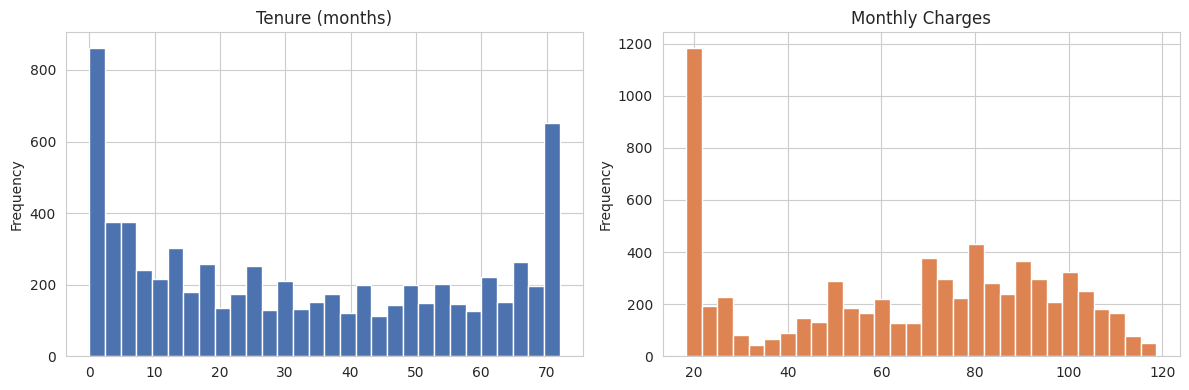

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['tenure'].plot(kind='hist', bins=30, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tenure (months)')
df['MonthlyCharges'].plot(kind='hist', bins=30, ax=axes[1], color='#DD8452')
axes[1].set_title('Monthly Charges')
plt.tight_layout()
plt.show()

Tenure is all over the place, but there's a big spike right at the start (0–5 months) and another smaller bump past 70 months — people either leave early or stay for years, not much in between. Monthly charges roughly split into a low cluster near \$20 (probably phone-only customers) and a wider spread from \$70–100 (internet plus add-ons).

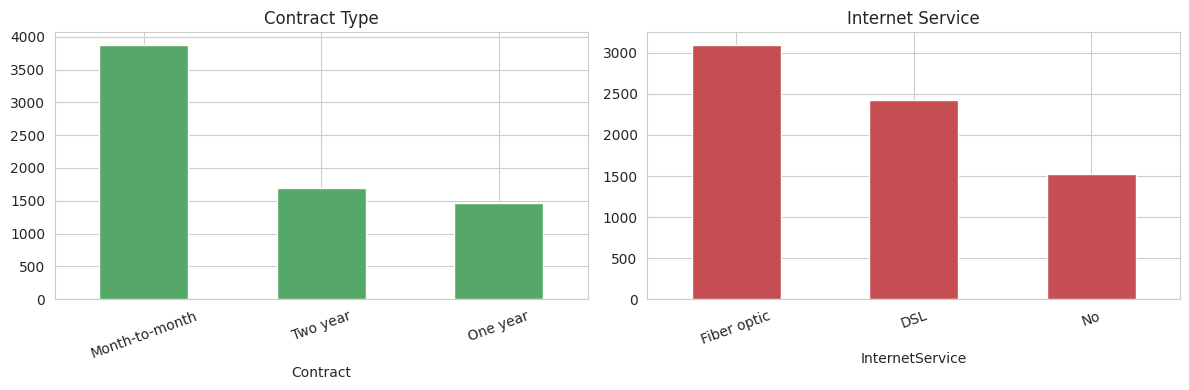

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Contract'].value_counts().plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Contract Type')
axes[0].tick_params(axis='x', rotation=20)
df['InternetService'].value_counts().plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Internet Service')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**12.** Most customers are month-to-month, well ahead of one-year and two-year combined — this company clearly isn't locking most people into long contracts. Fiber optic is the most common internet type, just ahead of DSL, and roughly 1 in 5 customers have no internet service at all.

In [15]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].skew()

tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963235
dtype: float64

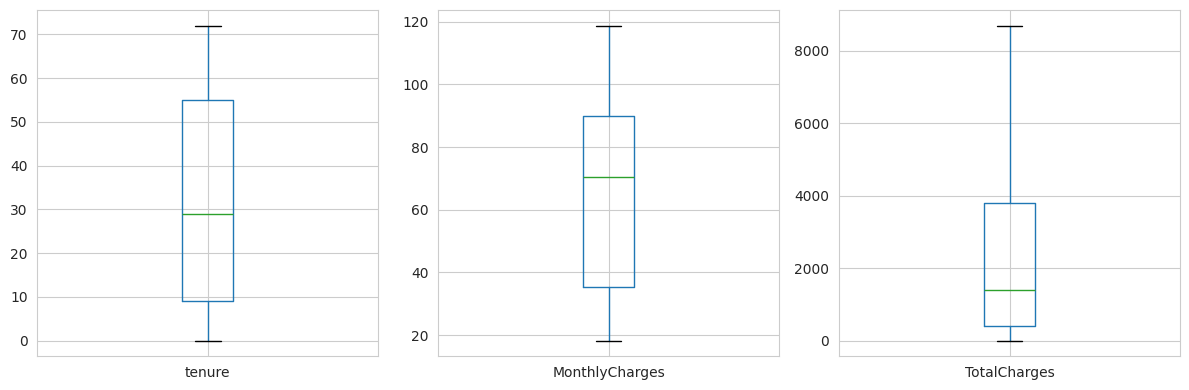

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
df.boxplot(column='tenure', ax=axes[0])
df.boxplot(column='MonthlyCharges', ax=axes[1])
df.boxplot(column='TotalCharges', ax=axes[2])
plt.tight_layout()
plt.show()

**13.** None of the three show real outliers on the boxplots — no points flying past the whiskers, everything sits in a sensible telecom-pricing range. `TotalCharges` is the most skewed (≈0.96) of the three, which tracks — it's roughly tenure × MonthlyCharges accumulated, so long-time high-paying customers pull the tail right. Nothing here looks like a data error, just a naturally skewed shape.

## Part 6 — Target Variable Analysis

In [17]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**14.** 5,174 customers stayed (about 73.5%), 1,869 churned (about 26.5%) — roughly a 3-to-1 split. That counts as imbalanced, though not extremely so.

**15.** With this kind of imbalance, a lazy model could just predict "No" for every customer and still be right ~73% of the time without learning anything real about who's actually at risk. Accuracy alone becomes a misleading metric here, and the model will naturally be worse at catching the minority Yes class — which is exactly the class the business cares about most.

## Part 7 — Bivariate Analysis: Features vs. Churn

In [19]:
(pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100).round(1)

Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


**16. Contract vs. Churn**
- Observation: churn drops hard as contract length goes up.
- Evidence: 42.7% churn on month-to-month, 11.3% on one-year, 2.8% on two-year.
- Possible explanation: month-to-month customers can leave with zero penalty, so naturally more of them do. Longer contracts either lock people in or just attract customers who were already planning to stay.

In [20]:
(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100).round(1)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


**PaymentMethod vs. Churn**
- Observation: electronic check users churn a lot more than everyone else.
- Evidence: 45.3% churn for electronic check vs. 15–19% for the other three methods.
- Possible explanation: electronic check needs a manual action every month instead of autopay, so it might just correlate with less-committed customers overall (fits with the contract finding) rather than causing churn on its own.

In [21]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


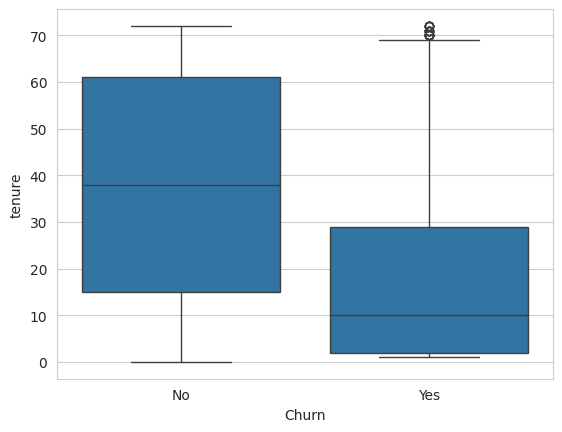

In [22]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

**17. tenure vs. Churn**
- Observation: churned customers are much newer on average.
- Evidence: average tenure is ~38 months for people who stayed vs. only ~18 months for people who left, with a median of just 10 months for churners.
- Possible explanation: the first year or so looks like the real danger zone — once someone sticks around a few years, they're far less likely to leave.

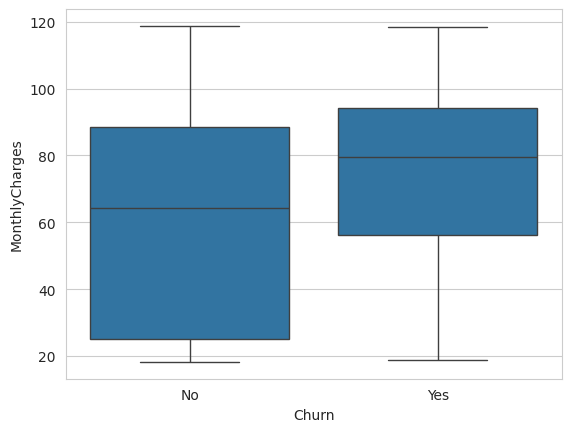

In [23]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

**MonthlyCharges vs. Churn**
- Observation: churners tend to pay more per month.
- Evidence: average monthly charge is ~\$74 for churners vs. ~\$61 for non-churners.
- Possible explanation: this likely ties back to InternetService — fiber optic customers pay more and also churn more, so this could be riding on that relationship rather than price alone driving it.

## Part 8 — Correlation & Feature Relationships

In [24]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
corr

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


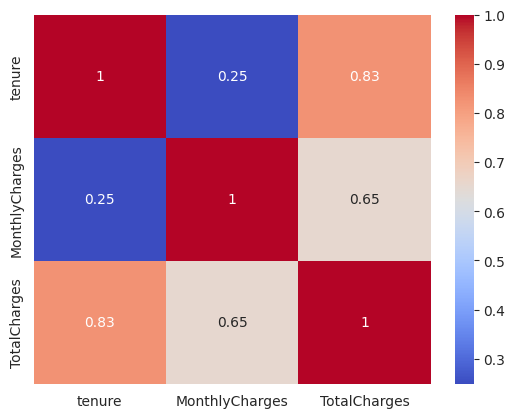

In [25]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

**18.** `tenure` and `TotalCharges` are strongly correlated (0.83) — makes sense, `TotalCharges` basically accumulates the longer someone stays. `MonthlyCharges` and `TotalCharges` are moderately correlated too (0.65).

**19.** No, correlation doesn't mean causation here — `tenure` and `TotalCharges` move together because one is roughly built out of the other (tenure × MonthlyCharges), not because either causes the other. Keeping both in a future model is somewhat redundant: they carry a lot of overlapping information, which can distort feature importance and make the model harder to interpret without adding much real predictive value.

## Part 9 — Data Leakage Awareness

**20.** `customerID` doesn't belong in the model, though that's really a "zero-signal feature" problem rather than leakage. The column I'd actually flag for leakage-style caution is `TotalCharges` — it's a running total up to the point the customer is observed (including the point some of them churned), so it indirectly encodes how long they lasted. For an early-lifecycle churn prediction, that's uncomfortably close to already knowing part of the answer. I don't see any explicit post-outcome column (like a cancellation date or reason) in this version of the dataset, which is good.

**21.** If a column like that were left in, the model would look great during training and testing because it's effectively cheating — using information it wouldn't actually have at the real moment of prediction. Then once it's deployed on genuinely new, still-active customers, that signal disappears and performance quietly collapses.

## Part 10 — ML-Readiness Checklist

**22.**

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per row, no predictive value |
| gender | Categorical | Feature | Keep, encode later | Practically no churn difference (26.9% vs 26.2%), weak but harmless |
| SeniorCitizen | Categorical (recoded) | Feature | Keep, encode later | Real gap in churn rate (23.6% vs 41.7%) |
| Partner | Categorical | Feature | Keep, encode later | Noticeable gap (33.0% vs 19.7%) |
| Dependents | Categorical | Feature | Keep, encode later | Similar pattern to Partner |
| tenure | Numerical | Feature | Keep, scale later | Strong relationship with churn |
| PhoneService | Categorical | Feature | Keep, low priority | Barely any churn difference (24.9% vs 26.7%) |
| MultipleLines | Categorical | Feature | Keep, encode later | Reflects service bundle size |
| InternetService | Categorical | Feature | Keep, encode later | Strong relationship (fiber optic churns most) |
| OnlineSecurity | Categorical | Feature | Keep, encode later | Add-on service, plausible churn link |
| OnlineBackup | Categorical | Feature | Keep, encode later | Add-on service, plausible churn link |
| DeviceProtection | Categorical | Feature | Keep, encode later | Add-on service, plausible churn link |
| TechSupport | Categorical | Feature | Keep, encode later | Add-on service, plausible churn link |
| StreamingTV | Categorical | Feature | Keep, encode later | Add-on service, plausible churn link |
| StreamingMovies | Categorical | Feature | Keep, encode later | Add-on service, plausible churn link |
| Contract | Categorical | Feature | Keep, encode later | Strongest bivariate relationship found |
| PaperlessBilling | Categorical | Feature | Keep, encode later | Billing behaviour, worth testing |
| PaymentMethod | Categorical | Feature | Keep, encode later | Strong relationship (electronic check churns most) |
| MonthlyCharges | Numerical | Feature | Keep, scale later | Clear churn relationship |
| TotalCharges | Numerical | Feature | Keep, watch for redundancy | Cleaned to numeric; highly correlated with tenure |
| Churn | Categorical | Target | Keep | This is what we're predicting |

## Part 11 — Building the Clean Dataset

**23.**

In [26]:
clean_df = df.drop(columns=['customerID']).copy()
clean_df.shape

(7043, 20)

In [27]:
clean_df.to_csv('clean_churn.csv', index=False)

**24.** Final proof everything's resolved:

In [28]:
clean_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   str    
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

## Part 12 — Key Findings & Final Reflection

**25. Five Key Findings**

**Finding 1 — Contract type drives churn more than anything else.**
Observation: churn falls sharply as contract length increases.
Evidence: 42.7% churn on month-to-month vs. 2.8% on two-year contracts.
Interpretation: the freedom to leave anytime is probably the single biggest churn risk factor in this dataset.

**Finding 2 — New customers are the most vulnerable.**
Observation: churners have much lower tenure than non-churners.
Evidence: median tenure of 10 months for churners vs. 38 for stayers.
Interpretation: the first year looks like the critical window for retention efforts.

**Finding 3 — Fiber optic and electronic-check customers churn more.**
Observation: both this internet type and this payment method show above-average churn.
Evidence: 41.9% churn for fiber optic vs. 19.0% for DSL; 45.3% churn for electronic check vs. 15–19% for the other payment methods.
Interpretation: possibly price- or friction-related — fiber is pricier, and electronic check needs an active monthly action instead of autopay.

**Finding 4 — The target is moderately imbalanced.**
Observation: about 73.5% stayed vs. 26.5% churned.
Evidence: exact counts of 5,174 vs. 1,869.
Interpretation: a future model can't be judged on accuracy alone — recall/precision on the churn class will matter more.

**Finding 5 — The "missing" data wasn't really missing.**
Observation: `TotalCharges` had 11 blank values, all for brand-new (tenure = 0) customers.
Evidence: `isnull()` found nothing, but checking for blank strings caught exactly 11 rows, every one at tenure = 0.
Interpretation: real-world missing data doesn't always show up as NaN — sometimes it's hiding in plain sight and needs a deliberate hunt.

**26. Final Reflection**

*Most important data-quality issue:* the `TotalCharges` blanks — small in number but easy to miss entirely since `isnull()` didn't flag them.

*Most interesting pattern:* how much contract type alone explains churn — a 40-point swing just between month-to-month and two-year customers.

*Feature most useful for predicting churn:* `Contract`, closely followed by `tenure`.

*Feature that probably shouldn't be used:* `customerID` — pure identifier, zero signal. `gender` is a close second for uselessness.

*Preprocessing needed before modeling (conceptually):* categorical columns need encoding, numerical columns need scaling since `tenure`/`MonthlyCharges`/`TotalCharges` sit on very different ranges, and the class imbalance needs a plan before training.

*What I'd do with another 3 hours:* engineer a couple of new features (like average charge per month of tenure, or tenure buckets such as new/mid/loyal), and check a few more combinations of add-on services against churn.

## Bonus — Churn Rate Across Two Segments at Once

In [29]:
(df.groupby(['Contract', 'InternetService'])['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)).round(1)

Contract        InternetService
Month-to-month  DSL                32.2
                Fiber optic        54.6
                No                 18.9
One year        DSL                 9.3
                Fiber optic        19.3
                No                  2.5
Two year        DSL                 1.9
                Fiber optic         7.2
                No                  0.8
Name: Churn, dtype: float64

Stacking two risk factors together makes the picture even sharper: month-to-month + fiber optic customers churn at 54.6% — by far the worst combination in the dataset — while two-year + no-internet customers barely churn at all (0.8%). Contract and internet type aren't just individually important, they seem to compound each other.